In [1]:
from typing import Any, Callable

from jaxtyping import Array
import equinox as eqx
import jax
import jax.numpy as jnp
from spyx.axn import arctan
import matplotlib.pyplot as plt

In [39]:
_spike_fn = arctan(k=2)
class FeLIF(eqx.Module):
    out_size: int = eqx.field(static=True)
    P_s: float = eqx.field(static=True)  # max polarisation
    A: float = eqx.field(static=True)
    C_tot_init: Array = eqx.field(static=True)
    step: Callable[[Any, Any], Any] = eqx.field(static=True)

    def __init__(
        self,
        out_size,
        A=25e-12,  # device area
        t_fe=9.8e-9,  # thikness ferroelectric
        eps_fe=70,  # ferroelectric dielectric constant
        eps_depl=3.6,  # interlayer dielectric constant
        q_fix_depl = 945e-4,
        n_depl = 1.4e28,
        e_off = 2e7,
        temp = 294,
        w_b = 1.05,
        d_e = 7.5e-9,
        P_s=27e-2,  # max polarisation
        I_0=1e-4,  # mult factor for leakage current
        V_t=0.32,  # normalization factor for voltage in leakage current
        C_par=15e-15,  # parasitic capacitance form the circuit
        I_dsc=10e-12,  # discharge current, set the "dendritic time constant"
        V_thr=3.5,
        dt=1e-3,  # 1us timestep resolution
        spike_fn=_spike_fn,
        paramScale = 1e12,
        *,
        key=None
    ):
        A = A * paramScale
        t_fe = t_fe * paramScale
        C_par = C_par * paramScale
        q_fix_depl = q_fix_depl * paramScale
        e_off = e_off / paramScale
        d_e = d_e * paramScale
        I_dsc = I_dsc * paramScale
        n_depl = n_depl / paramScale

        _eps0 = 8.85418792394420013968e-12 * paramScale
        _q = 1.60217663e-19 * paramScale
        _k = 1.380649e-23 * paramScale
        _h = 6.62607015e-34 * paramScale

        self.out_size = out_size

        # Initial values, to be checked whether sensible
        e_dummy = 0
        prob = 0
        
        C_fe = _eps0 * eps_fe / t_fe * A
        w_depl_d = ((_eps0 * eps_fe * e_dummy +  q_fix_depl) / _q / n_depl)
        w_depl_u = jnp.abs((_eps0 * eps_fe * e_dummy - q_fix_depl) / _q / n_depl)
        w_depl = (w_depl_d * w_depl_u / (prob * w_depl_u + (1 - prob) * w_depl_d))
        C_tot_init = 1/ (1/(C_fe + C_par) + 1/ (_eps0 * eps_depl / w_depl * A))

        #Save parameters in object
        self.A = A
        self.P_s = P_s
        self.C_tot_init = C_tot_init
        
        def step(state, input_):
            v, p, C_tot = state
            
            # Calculate spike
            threshold = V_thr * C_tot + P_s * self.A
            charge = v * C_tot + p * self.A
            spikes = spike_fn(charge - threshold)

            ### IEDM 2024
            e_dummy = v / t_fe
            prob = p / 2 / self.P_s + 0.5
            w_depl_d = ((_eps0 * eps_fe * e_dummy +  q_fix_depl) / _q / n_depl)
            w_depl_u = jnp.abs((_eps0 * eps_fe * e_dummy - q_fix_depl) / _q / n_depl)
            w_depl = (w_depl_d * w_depl_u / (prob * w_depl_u + (1 - prob) * w_depl_d))
            C_tot = 1/ (1/(C_fe + C_par) + 1/ (_eps0 * eps_depl / w_depl * self.A))
            # C_tot = 1/ (1/(C_fe + C_par))
            cap_divider = eps_depl / (t_fe * eps_depl + w_depl * eps_fe)
            depol_divider = 1 / _eps0 * w_depl / (t_fe * eps_depl + w_depl * eps_fe)

            E = v * cap_divider - p * depol_divider
            w_e = (E - e_off) * d_e
            k_plus =  _k * temp / _h * jnp.exp(-(w_b - w_e) * _q / _k / temp)
            dp = 2 * P_s * k_plus * (1 - prob) 
            I_p =  dp * A

            ### FeLIF
            I_leak = (I_0 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot
        
            v_upper = jnp.clip(v + dt * dv, 0, 5)
            p_upper = jnp.clip(p + dt * dp, -P_s, P_s)
            # p_upper = p + dt * dp
            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new, C_tot), (v_new, p_new, spikes, w_e)

        self.step = jax.jit(step)

    @eqx.filter_jit
    def getCharge(self, v, p, c=C_tot_init):
        return v * c + p * self.A

    @jax.named_scope("nn.FeLIF")
    def __call__(self, input_):
        v0 = jnp.zeros((self.out_size,))
        p0 = jnp.zeros((self.out_size,)) - self.P_s
        C_tot = jnp.zeros((self.out_size,)) + self.C_tot_init

        state = (v0, p0, C_tot)
        _, out = jax.lax.scan(self.step, state, input_)
        v, p, s, c = out

        return s, self.getCharge(v, p, c), v, p, c
FeLIF(1, spike_fn=_spike_fn, dt=1e-3, paramScale=1, key=None)
FeLIF(1, spike_fn=_spike_fn, dt=1e-3, paramScale=1e12, key=None)

FeLIF(
  out_size=1,
  P_s=0.27,
  A=25.0,
  C_tot_init=f32[],
  step=<wrapped function step>
)

In [45]:
t = jnp.linspace(0, 1, 100)
input = jnp.cos(8*t)
input = 50e-12*jnp.sign(input)*(input>0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-3, paramScale=1, key=None)
s, c, v, p, C_tot = felif(input)

t_us = jnp.linspace(0, 1, 100000)
input_us = jnp.cos(8*t_us)
input_us = 50e-12*jnp.sign(input_us)*(input_us>0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-6, paramScale=1, key=None)
s_us, c_us, v_us, p_us, C_tot_us = felif(input_us)

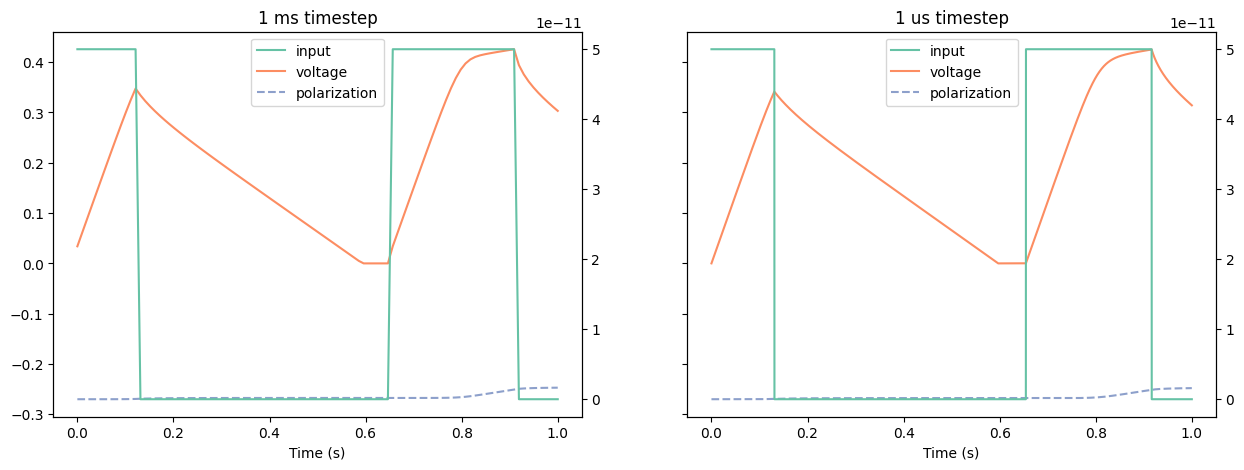

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
ax=axs[0].twinx()
lns1 = ax.plot(t, input, c="#66c2a5", label="input")
lns2 = axs[0].plot(t, v, c="#fc8d62", label="voltage")
lns3 = axs[0].plot(t, p, '--', c="#8da0cb", label="polarization")

# added these three lines
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[0].set_xlabel('Time (s)')
axs[0].set_title('1 ms timestep')

ax = axs[1].twinx()
lns1 = ax.plot(t_us, input_us, c="#66c2a5", label="input")
lns2 = axs[1].plot(t_us, v_us, c="#fc8d62", label="voltage")
lns3 = axs[1].plot(t_us, p_us, "--", c="#8da0cb", label="polarization")

# added these three lines
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[1].set_xlabel('Time (s)')
axs[1].set_title('1 us timestep')

plt.savefig('polloop.png')

[[0.11441302]]
[[nan]]


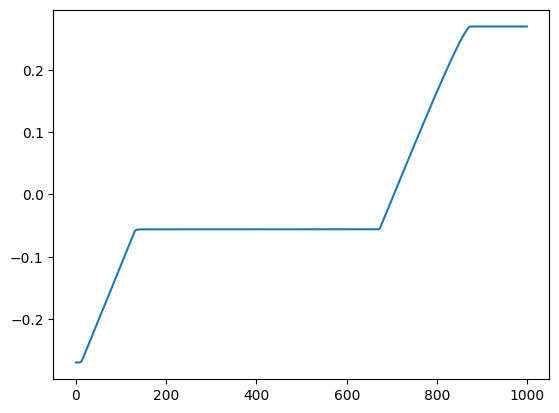

In [44]:
@eqx.filter_grad()
def loss_fn(model, input):
    s, _, _, _ = model(input)
    loss = jnp.sqrt((jnp.sum(s)-1)**2)
    return loss

t = jnp.linspace(0, 1, 1000)
input = jnp.cos(8*t)
input = 50e-12*jnp.sign(input)*(input>0.5)
input = input.reshape(-1,1)

@jax.custom_vjp
def grad_scaler(x):
  return x

def grad_scaler_fwd(x):
  return x, None

def grad_scaler_bwd(_, x_grad):
  return (x_grad*1e12,)

grad_scaler.defvjp(grad_scaler_fwd, grad_scaler_bwd)

class Network(eqx.Module):
    linear: eqx.nn.Linear
    felif: FeLIF

    def __init__(self):
        self.linear = eqx.nn.Linear(1, 1, use_bias=False, key=jax.random.key(0))
        self.felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-3, paramScale=1, key=None)

    def __call__(self, input):
        x = jax.vmap(self.linear)(input)
        s, c, v, p, C_tot = self.felif(x*10)
        return s, c, v, p

model = Network()
gradient = loss_fn(model, input)
gradient.linear.weight
print(model.linear.weight)
print(gradient.linear.weight)

_, c, v, p = model(input)
plt.plot(p)

In [3]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import matplotlib.pyplot as plt
import optax
from spyx.axn import superspike
from spyx.loaders import SHD_loader

In [4]:
_spike_fn = arctan(k=2)

class CUBALIF(eqx.Module):
    hidden_size: int = eqx.field(static=True)
    alpha: float = eqx.field(static=True)
    beta: float = eqx.field(static=True)
    recurrent: eqx.nn.Linear

    def __init__(self, hidden_size, alpha, beta, *, key=None):
        self.hidden_size = hidden_size
        self.alpha = alpha
        self.beta = beta
        self.recurrent = eqx.nn.Linear(hidden_size, hidden_size, key=key)

    def __call__(self, input_):
        hidden = (jnp.zeros((self.hidden_size,)), jnp.zeros((self.hidden_size,)))

        def f(carry, inp):
            syn, mem = carry

            mtr = mem - 1.0
            out = _spike_fn(mtr)
            rst = jax.lax.stop_gradient(out)

            new_syn = self.alpha * syn + inp + self.recurrent(out)
            new_mem = (self.beta * mem) * (1.0 - rst) + new_syn

            return (new_syn, new_mem), out

        _, out = jax.lax.scan(f, hidden, input_)

        return out

@jax.custom_vjp
def grad_scaler(x):
  return x

def grad_scaler_fwd(x):
  return x, None

def grad_scaler_bwd(_, x_grad):
  return (x_grad,)

grad_scaler.defvjp(grad_scaler_fwd, grad_scaler_bwd)

class Network(eqx.Module):
    layer1: CUBALIF
    linear1: eqx.nn.Linear

    layer2: FeLIF
    linear2: eqx.nn.Linear

    def __init__(self, in_size, hidden_size, out_size, alpha, beta, *, key):
        key1, key2, key3 = jax.random.split(key, 3)
        self.layer1 = CUBALIF(hidden_size, alpha, beta, key=key3)
        self.linear1 = eqx.nn.Linear(in_size, hidden_size, use_bias=False, key=key1)

        self.layer2 = FeLIF(out_size, spike_fn=_spike_fn, dt=1e-3)
        linear2 = eqx.nn.Linear(hidden_size, out_size, key=key2)

        get_weights = lambda m: m.weight
        new_weights = linear2.weight
        self.linear2 = eqx.tree_at(get_weights, linear2, new_weights)

    def __call__(self, input_):
        x1 = jax.vmap(self.linear1)(input_)
        s1 = self.layer1(x1)

        x2 = jax.vmap(self.linear2)(s1)
        s2, charge, v2, p2, _ = self.layer2(grad_scaler(x2*1e-10))

        return s2, (s1, charge, v2, p2)

In [5]:
batch_size = 128
nb_epochs = 1000
nb_steps = 72
nb_inputs = 700
nb_hidden = 200
nb_outputs = 20
learning_rate = 2e-4
time_step = 14e-3

tau_mem = 1680e-3
tau_syn = 5e-3

alpha = 0  # jnp.exp(-time_step/tau_syn)
beta = jnp.exp(-time_step / tau_mem)
shd_dl = SHD_loader(batch_size, nb_steps, nb_inputs, 0.2)

In [14]:
@jax.jit
def accuracy_fn(output, y):
    predicted_class = jnp.argmax(jnp.sum(output, axis=1), axis=1)
    return jnp.mean(predicted_class == y)

@eqx.filter_value_and_grad
def compute_loss(model, x, y):
    pred_y, (spks, _, _, _) = jax.vmap(model)(x)

    reg_loss1 = 2e-6 * jnp.sum(spks)
    reg_loss2 = 2e-6 * jnp.mean(
        jnp.sum(spks, axis=1) ** 2
    )  # L2 loss on spikes per neuron
    reg_loss3 = 2e-4*jnp.mean(jax.nn.relu(20-jnp.sum(pred_y, axis=(1, 2)))**2)

    m = jnp.sum(pred_y, axis=1)
    loss_val = (
        optax.softmax_cross_entropy(m, jax.nn.one_hot(y, nb_outputs)).mean()
        + reg_loss1
        + reg_loss2
        + reg_loss3
    )

    return loss_val

In [6]:
@eqx.filter_jit
def make_step(model, x, y, opt_state):
    loss, grads = compute_loss(model, x, y)

    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

@eqx.filter_jit
def epoch_step(state, data):
    model, opt_state = state
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    loss, model, opt_state = make_step(model, x, y, opt_state)

    return (model, opt_state), loss


@eqx.filter_jit
def test_step(model, data):
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    pred_y, (_, _, _, _) = jax.vmap(model)(x)

    return model, accuracy_fn(pred_y, y)

In [7]:
rngkey = jax.random.key(0)
model = Network(nb_inputs, nb_hidden, nb_outputs, alpha, beta, key=rngkey)
optim = optax.adamax(learning_rate, b1=0.9, b2=0.999)
opt_state = optim.init(model)

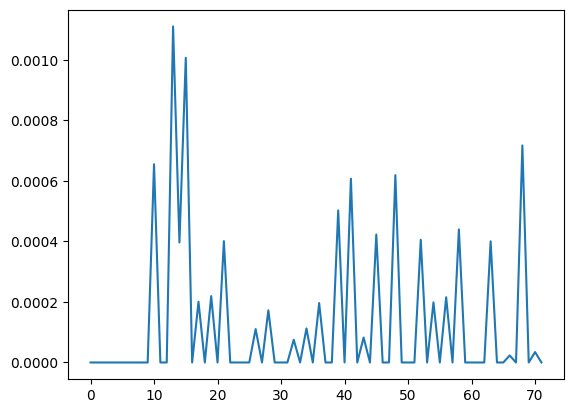

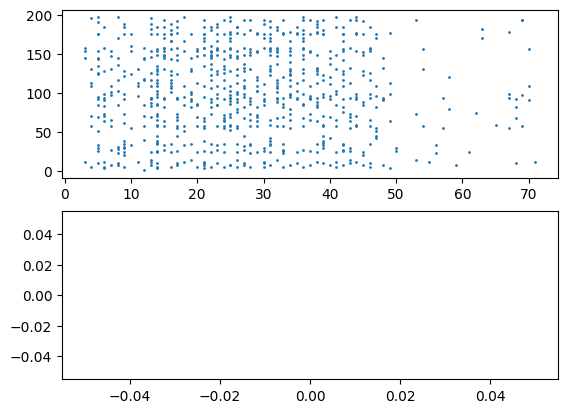

NameError: name 'compute_loss' is not defined

In [8]:
x_test, y_test = shd_dl.test_epoch()
x = jnp.unpackbits(x_test[1], axis=1)
pred_y, (s1, charge, voltage, polarization) = jax.vmap(model)(x)

plt.figure()
plt.plot(charge[3,:,0])
plt.show()

_, axs = plt.subplots(2, 1)
axs[0].scatter(*jnp.where(s1[0]), s=1)
axs[1].scatter(*jnp.where(pred_y[3]))
plt.show()
loss, gradients = compute_loss(model, x, y_test)

In [ ]:
gradients.linear1.weight

Array([[1.0734113e-05, 4.8203947e-06, 1.5081769e-05, ..., 2.1227344e-05,
        2.9931429e-05, 1.9600586e-05],
       [1.8606841e-05, 2.3729825e-05, 1.8973256e-05, ..., 1.9888327e-04,
        1.6757130e-04, 1.4324016e-04],
       [4.1826934e-06, 4.7040558e-06, 7.0710594e-06, ..., 2.2529035e-05,
        2.2028520e-05, 1.7164886e-05],
       ...,
       [9.9629746e-05, 9.1531547e-05, 8.7382155e-05, ..., 3.0834854e-04,
        2.8792207e-04, 2.6371283e-04],
       [3.6986003e-06, 4.3830496e-06, 7.0523965e-06, ..., 8.9969781e-06,
        1.0081089e-05, 8.7977969e-06],
       [6.8523914e-06, 6.2027248e-06, 1.2757999e-05, ..., 3.0205167e-05,
        2.5132920e-05, 2.4995927e-05]], dtype=float32)

In [ ]:
from tqdm import trange

total_loss = []
total_accuracy = []

pbar = trange(nb_epochs)
for epoch in pbar:
    epoch_key = jax.random.fold_in(rngkey, nb_epochs)
    x_train, y_train = shd_dl.train_epoch(epoch_key)
    (model, opt_state), loss = jax.lax.scan(
        epoch_step, (model, opt_state), (x_train, y_train)
    )

    x_test, y_test = shd_dl.test_epoch()
    _, accuracy = jax.lax.scan(test_step, model, (x_test, y_test))

    total_loss.append(jnp.mean(loss).item())
    total_accuracy.append(jnp.mean(accuracy).item())
    pbar.set_postfix({"loss": jnp.mean(loss), "accuracy": jnp.mean(accuracy)})
    # print(
    #     "Epoch %i: loss=%.5f accuracy=%.5f"
    #     % (epoch + 1, jnp.mean(loss), jnp.mean(accuracy))
    # )

    # if epoch % 10 == 0:
    #     # eqx.tree_serialise_leaves("shd.eqx", model)
    #     plt.figure()
    #     plt.plot(total_loss)
    #     plt.savefig("loss_polloop.png")

    #     plt.figure()
    #     plt.plot(total_accuracy)
    #     plt.savefig("accuracy_polloop.png")

plt.figure()
plt.plot(total_loss)
plt.savefig("loss_polloop.png")

plt.figure()
plt.plot(total_accuracy)
plt.savefig("accuracy_polloop.png")

  4%|▍         | 38/1000 [00:20<08:35,  1.86it/s, loss=3.0757325, accuracy=0.044577207] 


KeyboardInterrupt: 